# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [57]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.11.5 | pandas: 2.3.3


## 1. Target and audit
State the prediction moment, unit, population and target. Distinguish final classification from completing a race. Explain the source limitations. **COMPLETE**.

In [58]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

Add checks for duplicate keys, qualifying-only records, missing values and coverage. Explain what would happen with an inner join. TO COMPLETE.

In [59]:
train

,season,round,race_name,circuit_id,race_date,driver_id,driver_name,constructor_id,grid,position,position_text,status,points,laps,qualifying_position,qualifying_match,target_top10
0,2019,1,Australian Grand Prix,albert_park,2019-03-17,bottas,Valtteri Bottas,mercedes,2,1,1,Finished,26.0,58,2.0,both,1
1,2019,1,Australian Grand Prix,albert_park,2019-03-17,hamilton,Lewis Hamilton,mercedes,1,2,2,Finished,18.0,58,1.0,both,1
2,2019,1,Australian Grand Prix,albert_park,2019-03-17,max_verstappen,Max Verstappen,red_bull,4,3,3,Finished,15.0,58,4.0,both,1
3,2019,1,Australian Grand Prix,albert_park,2019-03-17,vettel,Sebastian Vettel,ferrari,3,4,4,Finished,12.0,58,3.0,both,1
4,2019,1,Australian Grand Prix,albert_park,2019-03-17,leclerc,Charles Leclerc,ferrari,5,5,5,Finished,10.0,58,5.0,both,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2021,22,Abu Dhabi Grand Prix,yas_marina,2021-12-12,latifi,Nicholas Latifi,williams,16,16,R,Accident,0.0,50,16.0,both,0
1196,2021,22,Abu Dhabi Grand Prix,yas_marina,2021-12-12,giovinazzi,Antonio Giovinazzi,alfa,14,17,R,Gearbox,0.0,33,14.0,both,0
1197,2021,22,Abu Dhabi Grand Prix,yas_marina,2021-12-12,russell,George Russell,williams,17,18,R,Gearbox,0.0,26,17.0,both,0
1198,2021,22,Abu Dhabi Grand Prix,yas_marina,2021-12-12,raikkonen,Kimi Räikkönen,alfa,18,19,R,Brakes,0.0,25,18.0,both,0


## ANSWER: Target and Audit

**Prediction moment** corresponds to right before the race starts; we need access to the grid slot, qualifying position, driver, constructor, circuit, and season/round, without including anything that happens **during** the race such as points, status or laps completed.

**Unit of observation** corresponds to one driver in one Grand Prix (one single driver-race pair per row).

**Population** corresponds to all driver-race pairs for qualified individuals that occur in 2019-2021.

Our **Target** is a binary (0 or 1) classificator, **target_top10**. It is equal to 1 if the driver is qualifying in the top 10, otherwise it equals 0. 


**The difference between qualifying and completing a race:**
- "status = finished" means that the driver completed the race, AKA they crossed the line after driving the full distance/laps.
- *Classification* is different from this, as a driver can classify for a race without having ending up finishing the target race. 

**Source limitations**:

Missing a couple of qualifying rows in 2019 and 2021. No weather data, tire allocation data, or penalty data. Data is mixed between integers and strings in **position_text**. Could disrupt data exploration. 


## Checks

In [60]:
import pandas as pd

# Assumes qualifying and results are already loaded as DataFrames,
# each with at least: season, round, driver_id

KEY = ["season", "round", "driver_id"]
qualifying = q_train
results = r_train
# ---------------------------------------------------------------
# a) Duplicate keys
# ---------------------------------------------------------------
def duplicate_key_report(df, name):
    dupe_mask = df.duplicated(subset=KEY, keep=False)
    n_dupe_rows = dupe_mask.sum()
    n_dupe_keys = df.loc[dupe_mask, KEY].drop_duplicates().shape[0] 
    print(f"[{name}] duplicate rows: {n_dupe_rows} | distinct duplicated keys: {n_dupe_keys}")
    if n_dupe_rows:
        display(df.loc[dupe_mask].sort_values(KEY).head(20))
    return df.loc[dupe_mask]

dupes_qual = duplicate_key_report(qualifying, "qualifying")
dupes_res  = duplicate_key_report(results, "results")

# ---------------------------------------------------------------
# b) Qualifying-only / results-only records (anti-joins)
# ---------------------------------------------------------------
qual_keys = qualifying[KEY].drop_duplicates()
res_keys  = results[KEY].drop_duplicates()

qual_only = qual_keys.merge(res_keys, on=KEY, how="left", indicator=True)
qual_only = qual_only[qual_only["_merge"] == "left_only"].drop(columns="_merge")

res_only = res_keys.merge(qual_keys, on=KEY, how="left", indicator=True)
res_only = res_only[res_only["_merge"] == "left_only"].drop(columns="_merge")

print(f"qualifying-only (no matching result): {len(qual_only)}")
print(f"results-only (no matching qualifying): {len(res_only)}")

# per-season breakdown
print("\nQualifying-only by season:")
print(qual_only.groupby("season").size())
print("\nResults-only by season:")
print(res_only.groupby("season").size())

# ---------------------------------------------------------------
# c) Missing values
# ---------------------------------------------------------------
qual_cols_to_check = ["qualifying_position"]   # add quali time/lap cols if present
res_cols_to_check  = ["grid", "position", "position_text", "status", "points", "laps"]

print("\n[qualifying] missing values:")
print(qualifying[qual_cols_to_check].isna().sum())

print("\n[results] missing values:")
print(results[res_cols_to_check].isna().sum())

# position is null but position_text is non-numeric -> expected (R, W, D, etc.)
# position is null but position_text LOOKS numeric -> real data problem
def is_numeric_text(x):
    try:
        int(x)
        return True
    except (TypeError, ValueError):
        return False

mask_bad = results["position"].isna() & results["position_text"].apply(is_numeric_text)
print(f"\nRows where position is null but position_text is numeric: {mask_bad.sum()}")
if mask_bad.sum():
    display(results.loc[mask_bad])

# non-numeric codes actually present in position_text
non_numeric_codes = results.loc[~results["position_text"].apply(is_numeric_text), "position_text"].unique()
print(f"Non-numeric position_text codes found: {sorted(non_numeric_codes)}")

# ---------------------------------------------------------------
# d) Coverage
# ---------------------------------------------------------------
cov_qual = qualifying.groupby("season").agg(
    rows=("driver_id", "size"),
    races=("round", "nunique"),
    drivers=("driver_id", "nunique"),
)
cov_res = results.groupby("season").agg(
    rows=("driver_id", "size"),
    races=("round", "nunique"),
    drivers=("driver_id", "nunique"),
)

coverage = cov_qual.join(cov_res, lsuffix="_qual", rsuffix="_res")
coverage["missing_qualifying"] = coverage["rows_res"] - coverage["rows_qual"]
print("\nCoverage by season:")
display(coverage)

# expected rows per season ≈ races * avg grid size — quick sanity check
coverage["avg_grid_per_race"] = coverage["rows_res"] / coverage["races_res"]
display(coverage[["races_res", "rows_res", "avg_grid_per_race"]])

# orphaned lookups (only meaningful once circuits/constructors tables are joined)
if "circuit_id" in results.columns:
    print("\nDistinct circuit_id with null/blank values:", results["circuit_id"].isna().sum())
if "constructor_id" in results.columns:
    print("Distinct constructor_id with null/blank values:", results["constructor_id"].isna().sum())

[qualifying] duplicate rows: 0 | distinct duplicated keys: 0
[results] duplicate rows: 0 | distinct duplicated keys: 0
qualifying-only (no matching result): 0
results-only (no matching qualifying): 3

Qualifying-only by season:
Series([], dtype: int64)

Results-only by season:
season
2019    2
2021    1
dtype: int64

[qualifying] missing values:
qualifying_position    0
dtype: int64

[results] missing values:
grid             0
position         0
position_text    0
status           0
points           0
laps             0
dtype: int64

Rows where position is null but position_text is numeric: 0
Non-numeric position_text codes found: ['D', 'R', 'W']

Coverage by season:


,rows_qual,races_qual,drivers_qual,rows_res,races_res,drivers_res,missing_qualifying
season,,,,,,,
2019,418,21,20,420,21,20,2
2020,340,17,23,340,17,23,0
2021,439,22,21,440,22,21,1


,races_res,rows_res,avg_grid_per_race
season,,,
2019,21,420,20.0
2020,17,340,20.0
2021,22,440,20.0



Distinct circuit_id with null/blank values: 0
Distinct constructor_id with null/blank values: 0


## 2. EDA question 1
Question: What is the empirical probability of a top-10 classification for each starting grid slot?

,grid,n_races,top10_rate
0,0,29,0.241379
1,1,60,0.916667
2,2,60,0.866667
3,3,60,0.883333
4,4,60,0.850000
5,5,60,0.750000
6,6,60,0.783333
7,7,59,0.661017
8,8,60,0.650000
9,9,60,0.666667


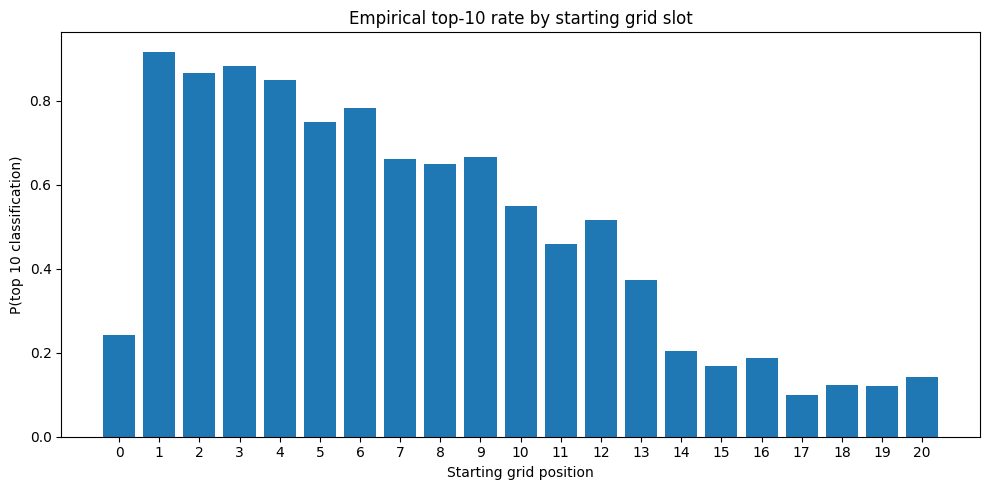

In [61]:
# Add your train-only analysis here.
import pandas as pd
top10_by_grid = (
    train.groupby("grid")["target_top10"]
    .agg(n_races="count", top10_rate="mean")
    .reset_index()
    .sort_values("grid")
)

display(top10_by_grid)

plt.figure(figsize=(10, 5))
plt.bar(top10_by_grid["grid"], top10_by_grid["top10_rate"])
plt.xlabel("Starting grid position")
plt.ylabel("P(top 10 classification)")
plt.title("Empirical top-10 rate by starting grid slot")
plt.xticks(top10_by_grid["grid"])
plt.tight_layout()
plt.show()

"0" in this case refers to participants that didn't have a starting grid position. This is one of the traps we saw last Thursday. 

## 3. EDA question 2
Question: Qualifying position vs. grid position. Do the two diverge often enough to matter (grid penalties), and does using one vs. the other change how strongly it predicts top10?

Rows with divergence: 381 / 1197 (31.8%)


count    1197.000000
mean       -0.424394
std         2.907493
min       -20.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        18.000000
Name: grid_penalty, dtype: float64

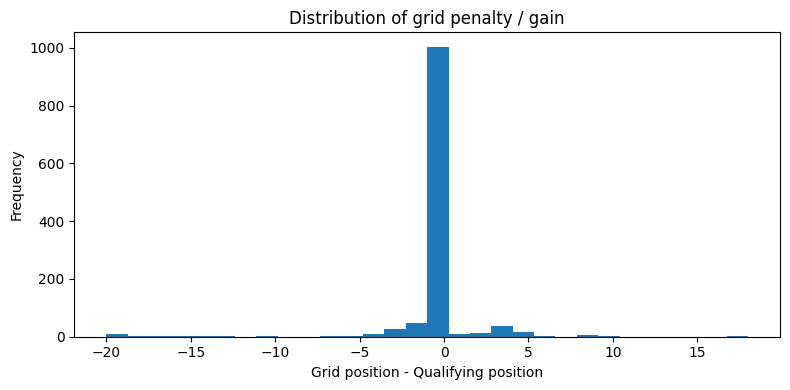

,position,n,top10_rate,source
20,0.0,29,0.241379,grid
21,1.0,60,0.916667,grid
22,2.0,60,0.866667,grid
23,3.0,60,0.883333,grid
24,4.0,60,0.850000,grid
25,5.0,60,0.750000,grid
26,6.0,60,0.783333,grid
27,7.0,59,0.661017,grid
28,8.0,60,0.650000,grid
29,9.0,60,0.666667,grid


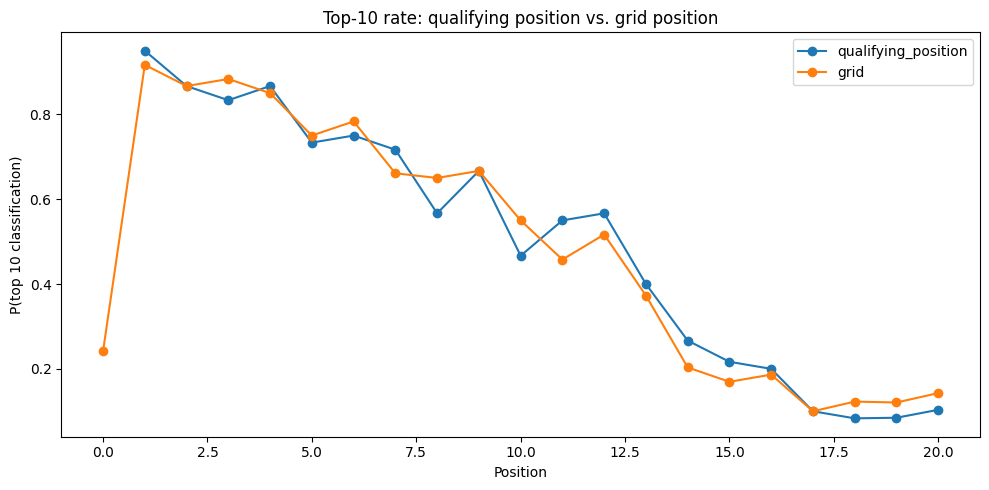

Correlation with target — qualifying_position: -0.567 | grid: -0.515


In [62]:
# --- How often do they diverge? ---
train["diverges"] = train["qualifying_position"] != train["grid"]

n_total = train["qualifying_position"].notna().sum()  # only rows with a quali position
n_diverge = train.loc[train["qualifying_position"].notna(), "diverges"].sum()

print(f"Rows with divergence: {n_diverge} / {n_total} ({n_diverge / n_total:.1%})")

train["grid_penalty"] = train["grid"] - train["qualifying_position"]
display(train["grid_penalty"].describe())

plt.figure(figsize=(8, 4))
train["grid_penalty"].dropna().plot(kind="hist", bins=30)
plt.xlabel("Grid position - Qualifying position")
plt.title("Distribution of grid penalty / gain")
plt.tight_layout()
plt.show()

# --- Does it change predictive strength for top10? ---
by_quali = (
    train.groupby("qualifying_position")["target_top10"]
    .agg(n="count", top10_rate="mean")
    .reset_index()
    .rename(columns={"qualifying_position": "position"})
)
by_quali["source"] = "qualifying_position"

by_grid = (
    train.groupby("grid")["target_top10"]
    .agg(n="count", top10_rate="mean")
    .reset_index()
    .rename(columns={"grid": "position"})
)
by_grid["source"] = "grid"

comparison = pd.concat([by_quali, by_grid], ignore_index=True)
display(comparison.sort_values(["source", "position"]))

plt.figure(figsize=(10, 5))
plt.plot(by_quali["position"], by_quali["top10_rate"], marker="o", label="qualifying_position")
plt.plot(by_grid["position"], by_grid["top10_rate"], marker="o", label="grid")
plt.xlabel("Position")
plt.ylabel("P(top 10 classification)")
plt.title("Top-10 rate: qualifying position vs. grid position")
plt.legend()
plt.tight_layout()
plt.show()

# quick numeric summary: correlation with target as a rough proxy for predictive strength
corr_quali = train["qualifying_position"].corr(train["target_top10"])
corr_grid = train["grid"].corr(train["target_top10"])
print(f"Correlation with target — qualifying_position: {corr_quali:.3f} | grid: {corr_grid:.3f}")

## 4. EDA question 3
**Question:** Does missing qualifying information create a selection trap that would make an inner join or complete-case analysis misleading?

The brief requires keeping result rows without qualifying records. I therefore compare the target rate for matched and unmatched qualifying records and inspect the exact unmatched cases. This is an explicit **selection-bias/trap check**: even if the missing share is small, deleting those rows changes the population and can change the errors made by the missing-value fallback.

Training rows: 1200
Missing qualifying: 3
Missing qualifying rate: 0.0025

Observations excluded by complete-case analysis:


,season,round,driver_id,driver_name,position,target_top10,status
49,2019,3,albon,Alexander Albon,10,1,+1 Lap
54,2019,3,giovinazzi,Antonio Giovinazzi,15,0,+1 Lap
857,2021,5,mick_schumacher,Mick Schumacher,18,0,+3 Laps



Full training population
Rows: 1200
Top-10 rate: 0.5

Complete-case population
Rows: 1197
Top-10 rate: 0.5004177109440268

Missing-qualifying group
Rows: 3
Top-10 rate: 0.3333333333333333


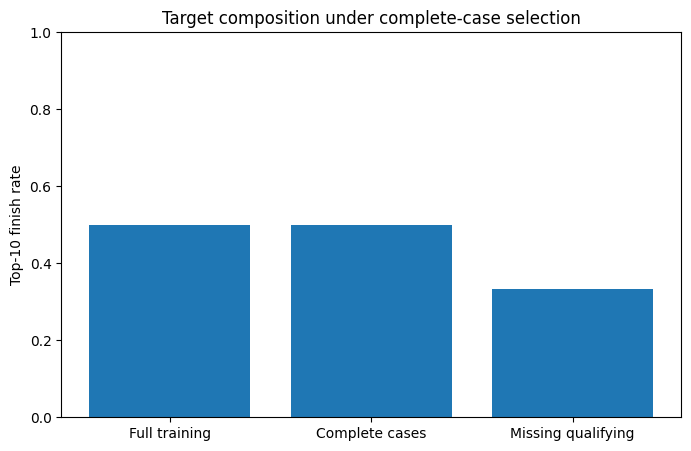

In [63]:
# Train-only EDA 3: missing-qualifying selection check
# 1. Measure missing qualifying information
print("Training rows:", len(train))
print(
    "Missing qualifying:",
    train["qualifying_position"].isna().sum()
)

missing_q = train[
    train["qualifying_position"].isna()
].copy()

print(
    "Missing qualifying rate:",
    len(missing_q) / len(train)
)

# 2. Inspect observations that would be removed
print("\nObservations excluded by complete-case analysis:")

display(
    missing_q[
        [
            "season",
            "round",
            "driver_id",
            "driver_name",
            "position",
            "target_top10",
            "status"
        ]
    ]
)

# 3. Compare the complete population with complete cases
complete_cases = train[
    train["qualifying_position"].notna()
].copy()

full_target_rate = train["target_top10"].mean()
complete_case_target_rate = complete_cases["target_top10"].mean()

print("\nFull training population")
print("Rows:", len(train))
print("Top-10 rate:", full_target_rate)

print("\nComplete-case population")
print("Rows:", len(complete_cases))
print("Top-10 rate:", complete_case_target_rate)

# 4. Examine the missing group itself
missing_target_rate = missing_q["target_top10"].mean()

print("\nMissing-qualifying group")
print("Rows:", len(missing_q))
print("Top-10 rate:", missing_target_rate)

import matplotlib.pyplot as plt

labels = [
    "Full training",
    "Complete cases",
    "Missing qualifying"
]

rates = [
    full_target_rate,
    complete_case_target_rate,
    missing_target_rate
]

plt.figure(figsize=(8, 5))
plt.bar(labels, rates)

plt.ylabel("Top-10 finish rate")
plt.title(
    "Target composition under complete-case selection"
)

plt.ylim(0, 1)
plt.show()

## 5. Baselines and 2022 check

The two rules are deliberately fixed and require no model fitting beyond the training-majority calculation.

1. **Training majority:** compute the most frequent target using only 2019–2021. Because the training target rate is exactly 50%, the rule encounters the specified exact tie and predicts `0`.
2. **Qualifying top ten:** predict `1` when `qualifying_position <= 10`; otherwise predict `0`. If qualifying position is missing, use the frozen training majority (`0`). The threshold of ten is fixed by the brief and is not re-estimated on calibration or test.

The majority rule is a trivial reference: it tells us how much performance comes simply from the class balance. The qualifying rule should fail mainly when a driver qualifies near the boundary but their race classification differs from the qualifying signal, or when race incidents move a driver across the top-ten boundary. The missing-value fallback can also create false negatives when an unmatched driver actually finishes in the top ten.

In [64]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


The confusion-matrix terms are interpreted relative to **final top-ten classification**:

- **TP:** predicted top ten and actually finished classified 1–10.
- **TN:** predicted outside top ten and actually classified outside 1–10.
- **FP:** predicted top ten but final classification was outside the top ten. This is a false alert: the rule says the driver is likely to be in the top ten, but the observed final classification is not.
- **FN:** predicted outside top ten but final classification was 1–10. This is a missed top-ten classification.

**Accuracy** is the fraction of all driver/race observations classified correctly. **Balanced accuracy** averages sensitivity for the positive class (top ten) and specificity for the negative class (outside top ten), so it is useful when comparing rules without letting the class balance dominate the interpretation. Here the training target is exactly balanced, so calibration accuracy and balanced accuracy coincide for the two rules.

For the 2022 check, the majority rule is expected to have 0% sensitivity because it always predicts 0. The qualifying rule can make both FP and FN errors because qualifying position is informative but not determinative of the final race result.

**Corrections after calibration:** none. The calibration check did not reveal a coding error or justify changing the frozen target, join, threshold, fallback, or temporal procedure. No test result was used to alter the method.

## 6. Freeze before final test

**Freeze record**

- **Members and date:** Álvaro Torres; second member Sebastián Ramorino. Freeze prepared 20 September 2026.
- **Target:** `1` for final race position 1–10, otherwise `0`.
- **Population:** all driver/race rows in the supplied results snapshots; keep retirements/non-finishers and missing qualifying.
- **Join:** left join from results to qualifying on `(season, round, driver_id)`.
- **Prediction moment:** after qualifying and before the Grand Prix.
- **Baselines:** training majority from 2019–2021; qualifying top ten with fixed threshold `<= 10`.
- **Training majority:** `0`, because the training target is exactly 50% and the specified tie rule predicts `0`.
- **Missing policy:** if `qualifying_position` is missing, use the frozen training majority `0`.
- **EDA decisions:** (1) use qualifying bands to inspect the signal around the fixed cutoff; (2) check stability of the fixed cutoff across 2019–2021; (3) explicitly retain and inspect missing-qualifying rows as a selection trap.
- **Calibration change:** none.
- **Frozen code commit/version:** b36cbd940aabc028086703208251902411d185c5. Do not change the method after inspecting 2023–2024 test outcomes.

This record is intentionally completed before `RUN_TEST` is enabled.

In [65]:
RUN_TEST=True
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test rows: 919 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,919.0,459.0,0.0,460.0,0.0,0.499456,0.500000
qualifying_top10,919.0,365.0,94.0,93.0,367.0,0.796518,0.796517


## 7. Final interpretation and handoff
The frozen **training-majority** value is `0` because the 2019–2021 target rate is exactly 50.0% and the specified tie rule predicts 0.

### 2022 calibration/check

| Rule | N | TN | FP | FN | TP | Accuracy | Balanced accuracy |
|---|---:|---:|---:|---:|---:|---:|---:|
| Training majority | 440 | 220 | 0 | 220 | 0 | 0.5000 | 0.5000 |
| Qualifying top ten | 440 | 168 | 52 | 52 | 168 | 0.7636 | 0.7636 |

There were **0 missing qualifying records** in the 2022 calibration set, so the majority fallback was not used there.

### 2023–2024 final test

| Rule | N | TN | FP | FN | TP | Accuracy | Balanced accuracy |
|---|---:|---:|---:|---:|---:|---:|---:|
| Training majority | 919 | 459 | 0 | 460 | 0 | 0.4995 | 0.5000 |
| Qualifying top ten | 919 | 365 | 94 | 93 | 367 | 0.7965 | 0.7965 |

There were **0 missing qualifying records** in the final test, so the fixed fallback was also unused there. The test consists of 440 driver/race rows from 2023 and 479 from 2024.

The observed comparison is clear without changing the frozen method: the **qualifying-top-ten rule achieved higher accuracy and balanced accuracy than the training-majority rule** in both the 2022 calibration and the 2023–2024 test. Its errors occur in both directions: on the final test it produced 94 false positives and 93 false negatives. In practical terms, qualifying position is informative but does not determine final classification; race incidents, performance changes and other pre-race factors can move a driver across the final top-ten boundary.

The majority rule is useful as a trivial reference because it shows what is obtained by ignoring qualifying information. Since the target is close to balanced in these snapshots, always predicting 0 gives accuracy close to 0.50 and balanced accuracy exactly 0.50.

The main limitation is the retrospective population: it is defined by records present in the supplied race-results snapshots, not by a complete pre-race entry list. Historical data can also contain later corrections. The analysis therefore evaluates the supplied snapshot and prediction rule, rather than claiming to reconstruct every piece of information available at the exact historical prediction time.

**Temporal integrity:** the 2019–2021 data were used for the audit/EDA and training majority; 2022 was used only as a calibration/check period; the method was frozen before 2023–2024 was opened. No threshold, feature, filtering rule or fallback was changed in response to test results.


Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.